<a href="https://colab.research.google.com/github/IsabelaZa26/Seguimiento-1/blob/main/Practica_RD_IC_mejorado_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Reducción de Dimensionalidad e Ingeniería de Características
**Introducción a la Minería de Datos — Semana 7**  
Verónica Guarín Escudero · Departamento de Estadística · Universidad Nacional de Colombia

---

## Objetivo del notebook

Este laboratorio pone en práctica los conceptos de la Semana 7 usando el dataset **Iris** como hilo conductor. Al finalizar, deberías ser capaz de:

- Identificar y eliminar columnas problemáticas (datos faltantes, baja varianza, alta correlación).
- Aplicar PCA para reducir dimensiones y visualizar el resultado.
- Medir la importancia de variables con Random Forest.
- Normalizar variables numéricas (Min-Max, Z-Score, Decimal Scaling, Robusto).
- Discretizar variables continuas (binning por igual ancho, igual frecuencia y basado en entropía).
- Recodificar variables categóricas con One-Hot Encoding.
- Calcular el Information Value (IV) y el Weight of Evidence (WoE) para selección supervisada de variables.

## Estructura del notebook

| Sección | Tema |
|---------|------|
| 1 | Librerías y carga de datos |
| 2 | Exploración inicial |
| 3 | **Reducción de Dimensionalidad** |
| 3.1 | Eliminar columnas con datos faltantes |
| 3.2 | Low Variance Filter |
| 3.3 | Columnas altamente correlacionadas |
| 3.4 | Variables importantes con Random Forest |
| 3.5 | Análisis de Componentes Principales (PCA) |
| 4 | **Ingeniería de Características** |
| 4.1 | Normalización (Min-Max, Z-Score, Decimal Scaling, Robusto) |
| 4.2 | Discretización (Binning: igual ancho, igual frecuencia) |
| 4.3 | Discretización basada en entropía |
| 4.4 | Recodificación de variables categóricas (One-Hot Encoding) |
| 5 | Resumen comparativo |
| 6 | **Ñapa: Information Value (IV) y Weight of Evidence (WoE)** |

---
## 1. Librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    KBinsDiscretizer, OneHotEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import pearsonr

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


---
## 2. Exploración inicial del dataset Iris

El dataset **Iris** contiene 150 observaciones de flores con 4 variables numéricas (dimensiones en cm del sépalo y pétalo) y una variable objetivo de 3 clases: *setosa*, *versicolor* y *virginica*.

> 💡 Aunque Iris es un dataset limpio, a lo largo del notebook **simularemos** condiciones reales (datos faltantes, variables redundantes, variables sesgadas) para que puedas ver cada técnica en acción.

In [2]:
# Cargar el dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Mapear etiquetas numéricas a nombres de especies
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_map)

print(f'Dimensiones: {df.shape}  →  {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones: (150, 6)  →  150 filas × 6 columnas


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# Estadísticas descriptivas
df.describe().round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000


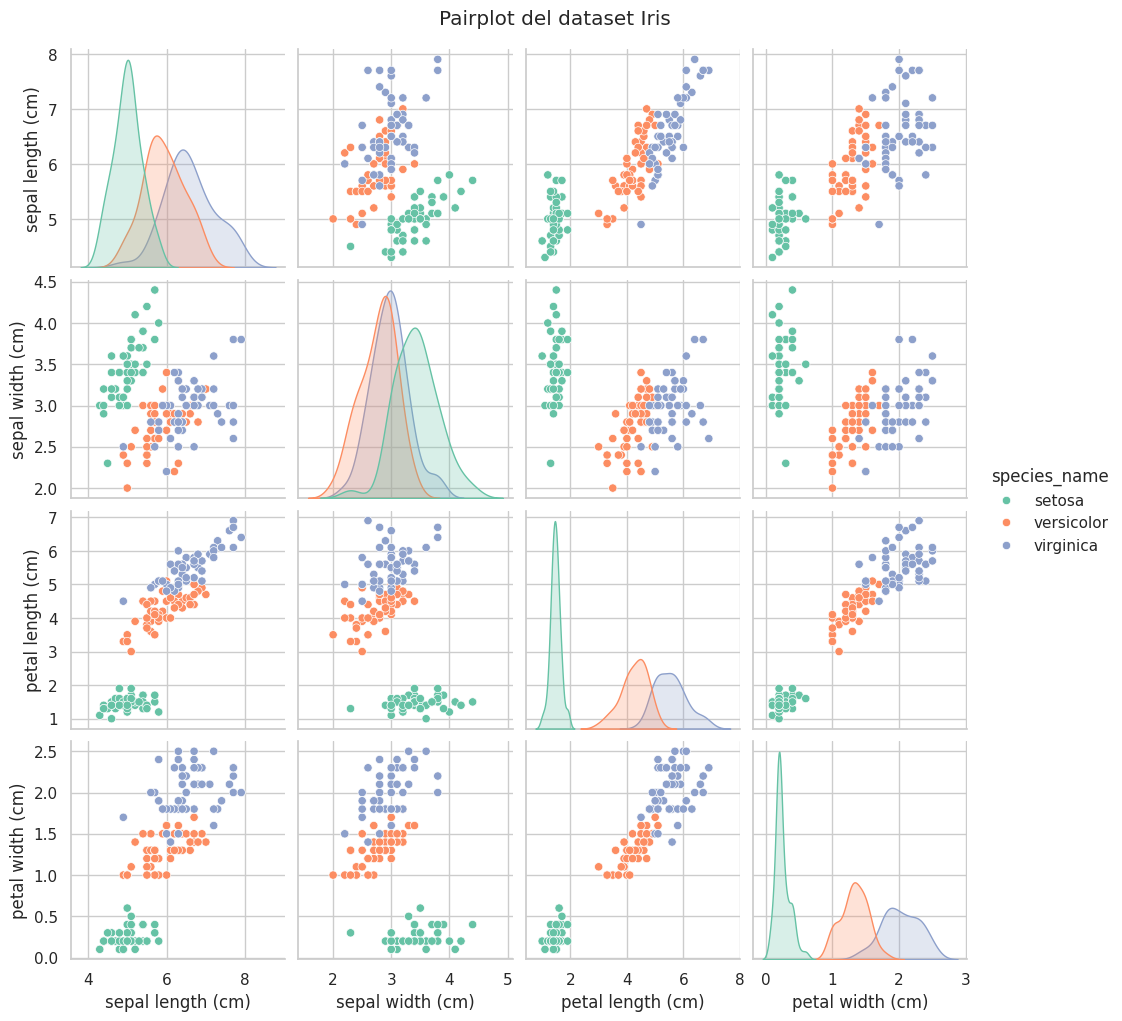

In [4]:
# Pairplot: distribución y relaciones entre variables por especie
sns.pairplot(df, hue='species_name', vars=iris.feature_names, diag_kind='kde')
plt.suptitle('Pairplot del dataset Iris', y=1.02)
plt.show()

---
## 3. Reducción de Dimensionalidad

La **reducción de dimensionalidad** consiste en remover atributos que no aportan información relevante. Esto combate la *maldición de la dimensionalidad*, que trae problemas como:

- **Espacio disperso**: las observaciones quedan muy separadas entre sí.
- **Dificultad para visualizar**: más de 3 dimensiones no se pueden graficar directamente.
- **Sobreajuste**: modelos más complejos se ajustan al ruido en lugar del patrón real.
- **Costo computacional**: más variables → mayor tiempo de entrenamiento.

Veremos 5 estrategias: eliminación por datos faltantes, filtro de varianza baja, eliminación de pares correlacionados, importancia con Random Forest y PCA.

### 3.1 Eliminar columnas con datos faltantes

**Concepto:** si una columna tiene un porcentaje alto de valores nulos (p. ej. más del 40 %) y no es posible imputar los valores faltantes de forma confiable, es mejor eliminarla.

**Criterio típico:** eliminar columnas con más del 40 % de valores nulos (puedes ajustar este umbral según tu problema).

Para demostrar la técnica, añadimos artificialmente columnas con muchos nulos al dataframe original.

In [5]:
# --- Simulación de datos faltantes ---
np.random.seed(42)
df_sim = df.copy()

# Columna con 70 % de nulos → debería eliminarse
df_sim['col_70pct_nulos'] = np.where(
    np.random.rand(len(df_sim)) < 0.70, np.nan, np.random.rand(len(df_sim))
)

# Columna con 20 % de nulos → se conserva (por debajo del umbral)
df_sim['col_20pct_nulos'] = np.where(
    np.random.rand(len(df_sim)) < 0.20, np.nan, np.random.rand(len(df_sim))
)

# Mostrar porcentaje de nulos por columna
pct_nulos = df_sim.isnull().mean().round(3) * 100
print('Porcentaje de valores nulos por columna:')
print(pct_nulos.to_string())

Porcentaje de valores nulos por columna:
sepal length (cm)     0.0
sepal width (cm)      0.0
petal length (cm)     0.0
petal width (cm)      0.0
species               0.0
species_name          0.0
col_70pct_nulos      70.0
col_20pct_nulos      24.7


In [6]:
# --- Aplicar el criterio de eliminación ---
UMBRAL_NULOS = 0.40  # 40 %

cols_antes = df_sim.shape[1]
df_sin_nulos = df_sim.loc[:, df_sim.isnull().mean() < UMBRAL_NULOS]
cols_despues = df_sin_nulos.shape[1]

cols_eliminadas = set(df_sim.columns) - set(df_sin_nulos.columns)
print(f'Columnas antes: {cols_antes}')
print(f'Columnas eliminadas: {cols_eliminadas}')
print(f'Columnas después: {cols_despues}')

Columnas antes: 8
Columnas eliminadas: {'col_70pct_nulos'}
Columnas después: 7


### 3.2 Low Variance Filter (Filtro de Varianza Baja)

**Concepto:** una variable con varianza cero o muy baja no discrimina entre observaciones — todos los valores son iguales o casi iguales. Eliminar estas variables no produce pérdida de información útil.

**Importante:** los datos deben **normalizarse** antes de comparar varianzas, para que el umbral sea independiente de la escala de cada variable.

**Criterio:** eliminar columnas cuya varianza (sobre datos normalizados) esté por debajo de un umbral `t`.

Varianza de cada columna (datos normalizados):
sepal length (cm)    0.05291
sepal width (cm)     0.03298
petal length (cm)    0.08952
petal width (cm)     0.10087
constante            0.00000
casi_constante       0.00000


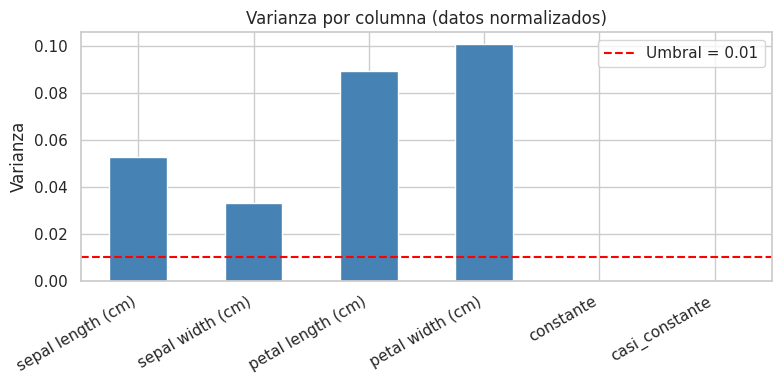

In [7]:
# Trabajamos solo con las columnas numéricas de Iris
X = df[iris.feature_names].copy()

# --- Paso 1: normalizar con Min-Max para que varianzas sean comparables ---
scaler_mm = MinMaxScaler()
X_norm = pd.DataFrame(scaler_mm.fit_transform(X), columns=X.columns)

# --- Paso 2: simular una columna constante (varianza = 0) ---
X_norm['constante'] = 1.0
X_norm['casi_constante'] = np.where(np.random.rand(len(X_norm)) < 0.95, 0.5, 0.51)

# --- Paso 3: calcular varianzas ---
varianzas = X_norm.var().round(5)
print('Varianza de cada columna (datos normalizados):')
print(varianzas.to_string())

# Visualizar varianzas
fig, ax = plt.subplots(figsize=(8, 4))
varianzas.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
UMBRAL_VAR = 0.01
ax.axhline(UMBRAL_VAR, color='red', linestyle='--', label=f'Umbral = {UMBRAL_VAR}')
ax.set_title('Varianza por columna (datos normalizados)')
ax.set_ylabel('Varianza')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# --- Aplicar filtro ---
cols_alta_var = varianzas[varianzas >= UMBRAL_VAR].index.tolist()
cols_baja_var = varianzas[varianzas < UMBRAL_VAR].index.tolist()

print(f'Columnas eliminadas por baja varianza: {cols_baja_var}')
print(f'Columnas conservadas: {cols_alta_var}')

Columnas eliminadas por baja varianza: ['constante', 'casi_constante']
Columnas conservadas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 3.3 Columnas altamente correlacionadas

**Concepto:** si dos variables tienen una correlación muy alta entre sí, una de ellas es redundante. Eliminar una no disminuye drásticamente la información disponible.

**Procedimiento:**
1. Calcular la matriz de correlaciones (Pearson para variables continuas).
2. Fijar un umbral (p. ej. 0.80).
3. Para cada par con correlación ≥ umbral, conservar la variable que tenga **menor** correlación promedio con el resto.

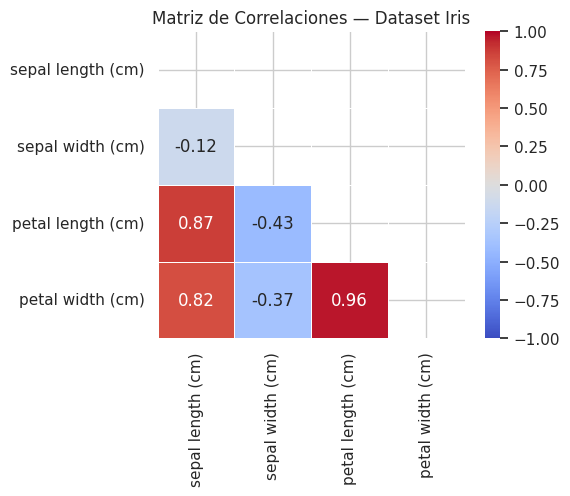

In [9]:
X_features = df[iris.feature_names]

# Matriz de correlaciones
corr_matrix = X_features.corr().round(3)

# Visualizar heatmap
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mostrar solo triángulo inferior
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Matriz de Correlaciones — Dataset Iris')
plt.tight_layout()
plt.show()

In [10]:
def eliminar_correlacionadas(df_num, umbral=0.80):
    """
    Dado un DataFrame numérico, identifica pares de columnas con correlación
    absoluta >= umbral y elimina la que tenga mayor correlación promedio con el
    resto (la más 'redundante').

    Retorna:
        cols_conservar  : lista de columnas a conservar
        cols_eliminar   : lista de columnas eliminadas
    """
    corr = df_num.corr().abs()
    # Triangulo superior sin diagonal
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    cols_eliminar = set()
    for col in upper.columns:
        # Pares donde la correlación supera el umbral
        pares = upper.index[upper[col] >= umbral].tolist()
        for par in pares:
            # Comparar correlación promedio con el resto
            mean_col = corr[col].drop(col).mean()
            mean_par = corr[par].drop(par).mean()
            # Eliminar la que tiene mayor correlación promedio
            cols_eliminar.add(col if mean_col >= mean_par else par)

    cols_conservar = [c for c in df_num.columns if c not in cols_eliminar]
    return cols_conservar, list(cols_eliminar)


UMBRAL_CORR = 0.80
conservar, eliminar = eliminar_correlacionadas(X_features, umbral=UMBRAL_CORR)

print(f'Umbral de correlación: {UMBRAL_CORR}')
print(f'Columnas eliminadas : {eliminar}')
print(f'Columnas conservadas: {conservar}')

Umbral de correlación: 0.8
Columnas eliminadas : ['petal width (cm)', 'petal length (cm)']
Columnas conservadas: ['sepal length (cm)', 'sepal width (cm)']


In [11]:
# Mostrar todos los pares con alta correlación
corr_abs = X_features.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
pares_altos = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlación'})
    .query('Correlación >= @UMBRAL_CORR')
    .sort_values('Correlación', ascending=False)
    .reset_index(drop=True)
)
print(f'Pares con |correlación| ≥ {UMBRAL_CORR}:')
pares_altos.round(3)

Pares con |correlación| ≥ 0.8:


,Variable 1,Variable 2,Correlación
0,petal length (cm),petal width (cm),0.963
1,sepal length (cm),petal length (cm),0.872
2,sepal length (cm),petal width (cm),0.818


### 3.4 Variables importantes con Random Forest

**Concepto:** un Random Forest mide la importancia de cada variable como la **reducción promedio de impureza** (Mean Decrease in Impurity / índice Gini) que aporta esa variable a lo largo de todos los árboles del bosque.

Las variables con importancia baja son candidatas a ser eliminadas sin afectar significativamente el rendimiento del modelo.

**Recuerda:**  
- Cada árbol se entrena con una muestra *bootstrap* (muestreo con reemplazo).  
- En cada nodo se elige un subconjunto aleatorio de features, lo que reduce la correlación entre árboles.  
- La predicción final es la clase con más votos (clasificación) o el promedio (regresión).

In [12]:
X_iris = df[iris.feature_names]
y_iris = df['species']

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_iris, y_iris)

# Tabla de importancias
importancias = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print('Importancia de variables (Mean Decrease in Impurity):')
importancias.round(4)

Importancia de variables (Mean Decrease in Impurity):


,Feature,Importancia
0,petal length (cm),0.4593
1,petal width (cm),0.4179
2,sepal length (cm),0.1020
3,sepal width (cm),0.0209


/tmp/ipykernel_1153/871411305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


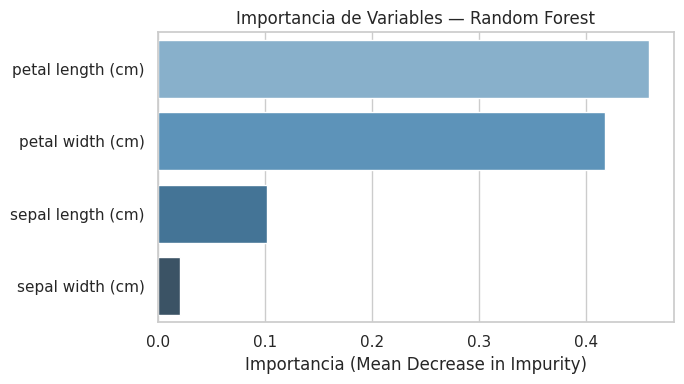


Variables seleccionadas (importancia ≥ 0.05): ['petal length (cm)', 'petal width (cm)', 'sepal length (cm)']


In [13]:
# Visualización
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=importancias, x='Importancia', y='Feature',
    palette='Blues_d', ax=ax
)
ax.set_title('Importancia de Variables — Random Forest')
ax.set_xlabel('Importancia (Mean Decrease in Impurity)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Seleccionar variables con importancia >= umbral
UMBRAL_IMP = 0.05
vars_seleccionadas = importancias.query('Importancia >= @UMBRAL_IMP')['Feature'].tolist()
print(f'\nVariables seleccionadas (importancia ≥ {UMBRAL_IMP}): {vars_seleccionadas}')

### 3.5 Análisis de Componentes Principales (PCA)

**Concepto:** PCA es una técnica de **transformación** (no de selección) que proyecta los datos originales en un nuevo espacio de menor dimensión, capturando la mayor cantidad posible de varianza.

**Pasos:**
1. **Estandarizar** los datos (media 0, desviación 1) — PCA es sensible a la escala.
2. Calcular la **matriz de covarianza**.
3. Obtener los **valores propios** (cuánta varianza explica cada dirección) y los **vectores propios** (dirección de cada componente).
4. Ordenar componentes de mayor a menor varianza explicada.
5. **Proyectar** los datos sobre los primeros `k` componentes.

Las componentes principales **no son interpretables** como las variables originales, pero permiten visualizar y comprimir los datos.

> ⚠️ PCA solo aplica a variables numéricas.

In [14]:
# --- Paso 1: Estandarizar ---
scaler_z = StandardScaler()
X_scaled = scaler_z.fit_transform(X_iris)

# --- Paso 2 y 3: PCA con todas las componentes ---
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla de varianza explicada
pca_table = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': (varianza_explicada * 100).round(2),
    'Varianza Acumulada (%)': (varianza_acumulada * 100).round(2)
})
print(pca_table.to_string(index=False))

Componente  Varianza Explicada (%)  Varianza Acumulada (%)
       PC1                   72.96                   72.96
       PC2                   22.85                   95.81
       PC3                    3.67                   99.48
       PC4                    0.52                  100.00


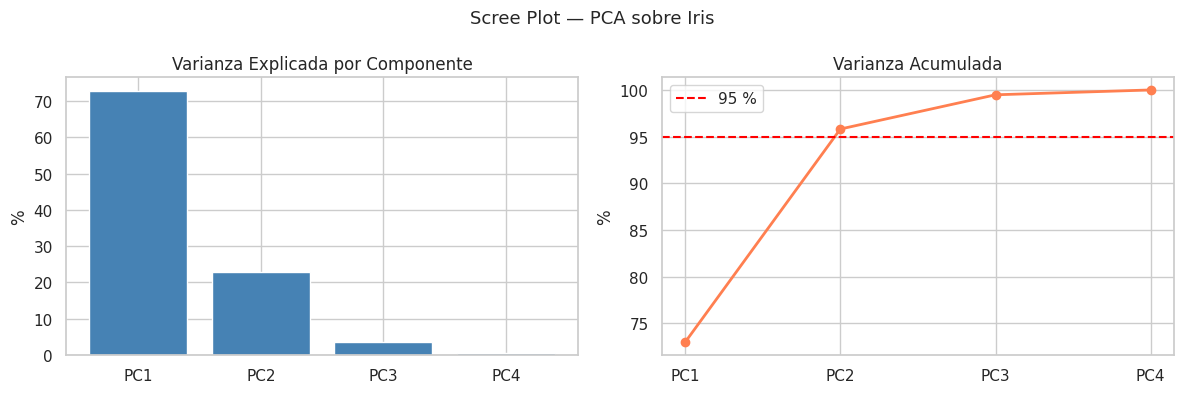


📌 Con 2 componentes se explica el 95.8 % de la varianza.


In [15]:
# --- Gráfica Scree Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Varianza individual
axes[0].bar(
    pca_table['Componente'], pca_table['Varianza Explicada (%)'],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Varianza Explicada por Componente')
axes[0].set_ylabel('%')

# Varianza acumulada
axes[1].plot(
    pca_table['Componente'], pca_table['Varianza Acumulada (%)'],
    marker='o', color='coral', linewidth=2
)
axes[1].axhline(95, color='red', linestyle='--', label='95 %')
axes[1].set_title('Varianza Acumulada')
axes[1].set_ylabel('%')
axes[1].legend()

plt.suptitle('Scree Plot — PCA sobre Iris', fontsize=13)
plt.tight_layout()
plt.show()

print('\n📌 Con 2 componentes se explica el', round(varianza_acumulada[1]*100, 1), '% de la varianza.')

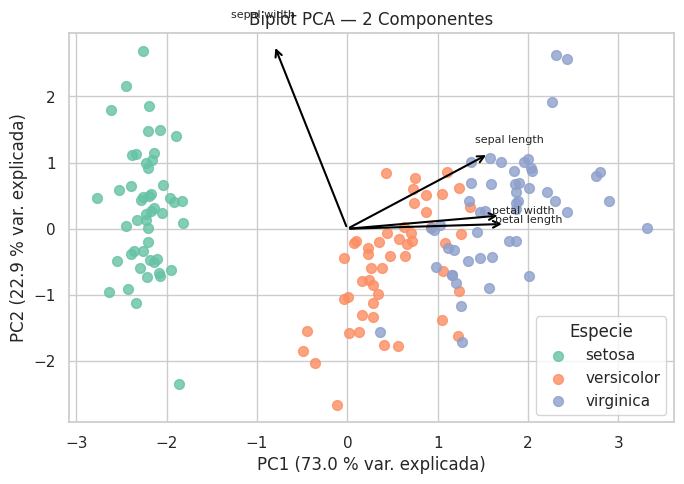

In [16]:
# --- Proyección en 2D (PC1 vs PC2) ---
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = df['species_name'].values

fig, ax = plt.subplots(figsize=(7, 5))
for especie, grupo in pca_df.groupby('species'):
    ax.scatter(grupo['PC1'], grupo['PC2'], label=especie, s=50, alpha=0.8)

# Añadir vectores de carga (loadings)
loadings = pca_2d.components_.T
scale = 3
for i, feat in enumerate(iris.feature_names):
    ax.annotate(
        '', xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
    )
    ax.text(
        loadings[i, 0] * scale * 1.15,
        loadings[i, 1] * scale * 1.15,
        feat.replace(' (cm)', ''), fontsize=8, ha='center'
    )

ax.set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f} % var. explicada)')
ax.set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f} % var. explicada)')
ax.set_title('Biplot PCA — 2 Componentes')
ax.legend(title='Especie')
plt.tight_layout()
plt.show()

In [17]:
# --- Tabla de loadings (contribución de cada variable a cada PC) ---
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=iris.feature_names,
    columns=['PC1', 'PC2']
).round(3)
print('Loadings (contribución de cada variable a cada componente):')
loadings_df

Loadings (contribución de cada variable a cada componente):


,PC1,PC2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


---
## 4. Ingeniería de Características

La **Ingeniería de Características** (Feature Engineering) mejora el rendimiento del modelado transformando el espacio de variables. Incluye:
- **Normalización**: escalar variables a un rango común.
- **Discretización**: convertir variables continuas en categorías.
- **Recodificación**: convertir variables categóricas en numéricas.

### 4.1 Normalización

La normalización escala los valores numéricos para hacerlos comparables entre sí. Es especialmente importante en algoritmos basados en distancias (KNN, clustering) y en gradiente descendente.

#### Métodos:

| Método | Fórmula | Rango resultante | Sensible a outliers |
|--------|---------|-----------------|---------------------|
| **Min-Max** | $X^* = \dfrac{X - \min(X)}{\max(X) - \min(X)}$ | [0, 1] | Sí |
| **Z-Score** | $Z = \dfrac{X - \mu}{\sigma}$ | Sin límite (≈ -3 a 3) | Moderadamente |
| **Decimal Scaling** | $X_d = \dfrac{X}{10^d}$ | (-1, 1) | No |
| **Robusto (IQR)** | $X_r = \dfrac{X - Q_2}{Q_3 - Q_1}$ | Sin límite fijo | No |

Donde $d$ es el número de dígitos del valor absoluto máximo.

In [18]:
# Tomamos 'sepal length (cm)' como ejemplo (igual que en las diapositivas)
col = 'sepal length (cm)'
X_col = df[[col]].copy()

# --- Min-Max ---
mm = MinMaxScaler()
df[col + '_minmax'] = mm.fit_transform(X_col)

# --- Z-Score ---
zs = StandardScaler()
df[col + '_zscore'] = zs.fit_transform(X_col)

# --- Decimal Scaling ---
max_abs = X_col[col].abs().max()
d = len(str(int(max_abs)))          # Número de dígitos de la parte entera del máximo
df[col + '_decimal'] = X_col[col] / (10 ** d)

# --- Robusto (mediana e IQR) ---
rs = RobustScaler()
df[col + '_robusto'] = rs.fit_transform(X_col)

# Mostrar las primeras filas con todas las versiones
cols_norm = [col, col+'_minmax', col+'_zscore', col+'_decimal', col+'_robusto']
df[cols_norm].head(10).round(4)

,sepal length (cm),sepal length (cm)_minmax,sepal length (cm)_zscore,sepal length (cm)_decimal,sepal length (cm)_robusto
0,5.1,0.2222,-0.9007,0.51,-0.5385
1,4.9,0.1667,-1.1430,0.49,-0.6923
2,4.7,0.1111,-1.3854,0.47,-0.8462
3,4.6,0.0833,-1.5065,0.46,-0.9231
4,5.0,0.1944,-1.0218,0.50,-0.6154
5,5.4,0.3056,-0.5372,0.54,-0.3077
6,4.6,0.0833,-1.5065,0.46,-0.9231
7,5.0,0.1944,-1.0218,0.50,-0.6154
8,4.4,0.0278,-1.7489,0.44,-1.0769
9,4.9,0.1667,-1.1430,0.49,-0.6923


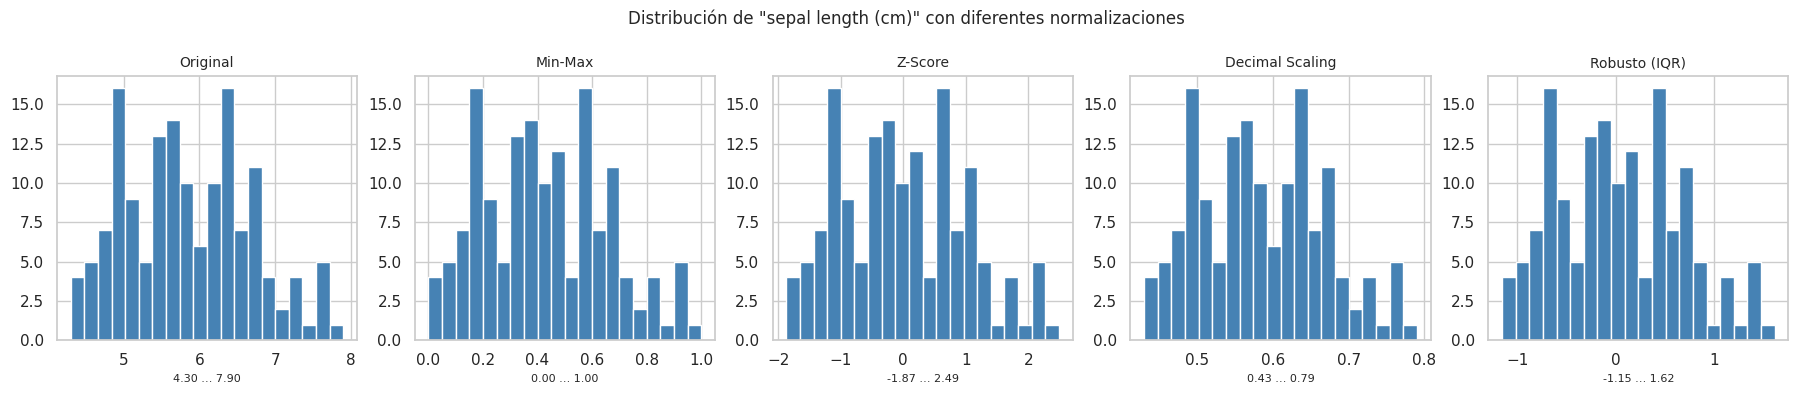


📌 Nota: la FORMA de la distribución no cambia, solo la escala.


In [19]:
# --- Visualización comparativa de distribuciones ---
titulos = ['Original', 'Min-Max', 'Z-Score', 'Decimal Scaling', 'Robusto (IQR)']
data_cols = cols_norm

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, col_plot, titulo in zip(axes, data_cols, titulos):
    ax.hist(df[col_plot], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(titulo, fontsize=10)

    # Calculamos min y max primero para que el código sea legible
    val_min = df[col_plot].min()
    val_max = df[col_plot].max()

    # Usamos f-strings para formatear a 2 decimales y convertir a texto automáticamente
    ax.set_xlabel(f"{val_min:.2f} … {val_max:.2f}", fontsize=8)

fig.suptitle(f'Distribución de "{col}" con diferentes normalizaciones', fontsize=12)
plt.tight_layout()
plt.show()

print('\n📌 Nota: la FORMA de la distribución no cambia, solo la escala.')

In [20]:
# Estadísticas descriptivas de cada versión normalizada
df[cols_norm].describe().round(4)

,sepal length (cm),sepal length (cm)_minmax,sepal length (cm)_zscore,sepal length (cm)_decimal,sepal length (cm)_robusto
count,150.0000,150.0000,150.0000,150.0000,150.0000
mean,5.8433,0.4287,-0.0000,0.5843,0.0333
std,0.8281,0.2300,1.0034,0.0828,0.6370
min,4.3000,0.0000,-1.8700,0.4300,-1.1538
25%,5.1000,0.2222,-0.9007,0.5100,-0.5385
50%,5.8000,0.4167,-0.0525,0.5800,0.0000
75%,6.4000,0.5833,0.6745,0.6400,0.4615
max,7.9000,1.0000,2.4920,0.7900,1.6154


### 4.2 Discretización — Binning

**Concepto:** la discretización convierte una variable continua en categorías o intervalos. Esto:
- Simplifica la representación de los datos.
- Puede ayudar a ciertos algoritmos que trabajan mejor con variables categóricas.
- Reduce el efecto de los outliers.

#### Tipos de Binning (no supervisado):
- **Igual Ancho (Equal Width):** divide el rango en `k` intervalos del mismo tamaño.  
  → Sencillo, pero puede dejar bins vacíos si hay outliers.
- **Igual Frecuencia (Equal Frequency / Quantiles):** cada bin contiene el mismo número de observaciones.  
  → Mejor distribución de datos, respeta la densidad.

Trabajaremos con `petal length (cm)` dividida en 3 categorías.

In [21]:
col_disc = 'petal length (cm)'
K = 3  # Número de bins
labels_bins = ['Bajo', 'Medio', 'Alto']

# --- Igual Ancho ---
kbd_ancho = KBinsDiscretizer(n_bins=K, encode='ordinal', strategy='uniform')
df['petal_length_igulancho'] = kbd_ancho.fit_transform(df[[col_disc]]).astype(int)
df['petal_length_igulancho_lbl'] = df['petal_length_igulancho'].map(
    {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
)

edges_ancho = kbd_ancho.bin_edges_[0].round(3)
print(f'Igual Ancho — Bordes de bins: {edges_ancho}')
print(df.groupby('petal_length_igulancho_lbl')[col_disc].agg(['min','max','count']))

print()

# --- Igual Frecuencia ---
kbd_freq = KBinsDiscretizer(n_bins=K, encode='ordinal', strategy='quantile')
df['petal_length_igualfreq'] = kbd_freq.fit_transform(df[[col_disc]]).astype(int)
df['petal_length_igualfreq_lbl'] = df['petal_length_igualfreq'].map(
    {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
)

edges_freq = kbd_freq.bin_edges_[0].round(3)
print(f'Igual Frecuencia — Bordes de bins: {edges_freq}')
print(df.groupby('petal_length_igualfreq_lbl')[col_disc].agg(['min','max','count']))

Igual Ancho — Bordes de bins: [1.    2.967 4.933 6.9  ]
                            min  max  count
petal_length_igulancho_lbl                 
Alto                        5.0  6.9     46
Bajo                        1.0  1.9     50
Medio                       3.0  4.9     54

Igual Frecuencia — Bordes de bins: [1.    2.633 4.9   6.9  ]
                            min  max  count
petal_length_igualfreq_lbl                 
Alto                        4.9  6.9     51
Bajo                        1.0  1.9     50
Medio                       3.0  4.8     49


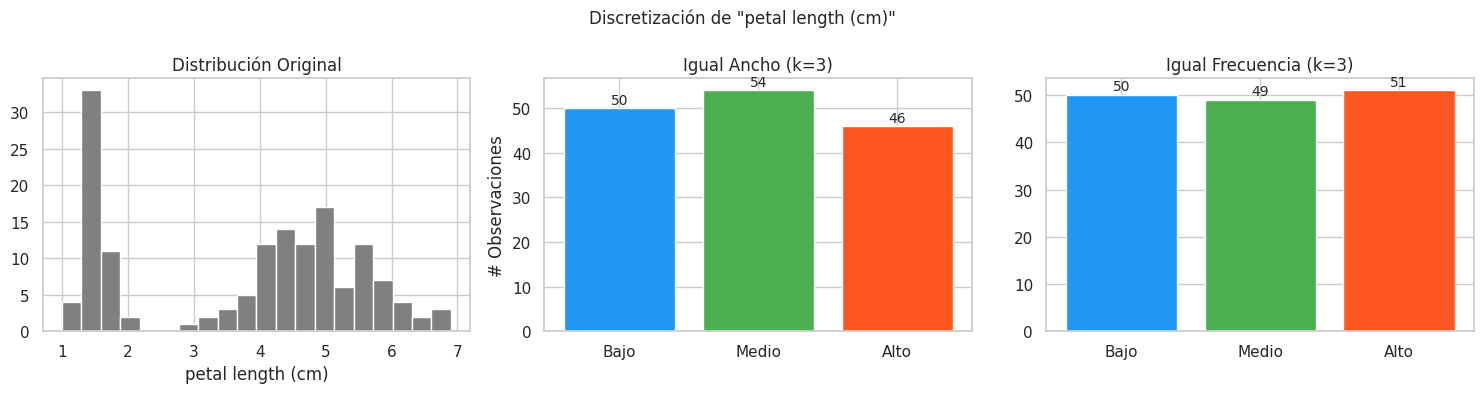

In [22]:
# Visualización comparativa de los dos métodos de binning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = {'Bajo': '#2196F3', 'Medio': '#4CAF50', 'Alto': '#FF5722'}

# Original
axes[0].hist(df[col_disc], bins=20, color='gray', edgecolor='white')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel(col_disc)

# Igual Ancho — barras de conteo por bin
conteo_ancho = df['petal_length_igulancho_lbl'].value_counts().reindex(labels_bins)
axes[1].bar(conteo_ancho.index, conteo_ancho.values,
            color=[colores[l] for l in conteo_ancho.index], edgecolor='white')
for ix, (lbl, cnt) in enumerate(conteo_ancho.items()):
    axes[1].text(ix, cnt + 1, str(cnt), ha='center', fontsize=10)
axes[1].set_title(f'Igual Ancho (k={K})')
axes[1].set_ylabel('# Observaciones')

# Igual Frecuencia
conteo_freq = df['petal_length_igualfreq_lbl'].value_counts().reindex(labels_bins)
axes[2].bar(conteo_freq.index, conteo_freq.values,
            color=[colores[l] for l in conteo_freq.index], edgecolor='white')
for ix, (lbl, cnt) in enumerate(conteo_freq.items()):
    axes[2].text(ix, cnt + 1, str(cnt), ha='center', fontsize=10)
axes[2].set_title(f'Igual Frecuencia (k={K})')

fig.suptitle(f'Discretización de "{col_disc}"', fontsize=12)
plt.tight_layout()
plt.show()

### 4.3 Discretización basada en Entropía (Supervisada)

**Concepto:** en lugar de dividir según el rango o la frecuencia, este método busca los puntos de corte que **maximizan la ganancia de información** con respecto a la variable objetivo. Es un método **supervisado**.

**Fórmulas clave:**

$$H(Y) = -\sum_{i=1}^{k} p(C_i) \log_2 p(C_i) \quad \text{(entropía de la clase)}$$

$$H(Y|X, t) = P(X \leq t) \cdot H(Y|X \leq t) + P(X > t) \cdot H(Y|X > t) \quad \text{(entropía tras el corte)}$$

$$\text{IG} = H(Y) - H(Y|X, t) \quad \text{(ganancia de información)}$$

El **mejor punto de corte** es el que maximiza IG (o equivalentemente, minimiza $H(Y|X, t)$).

#### Opción A: implementación manual del mejor split

In [23]:
def entropia(y):
    """Calcula la entropía de Shannon de un arreglo de etiquetas."""
    if len(y) == 0:
        return 0
    counts = np.bincount(y)
    probs = counts[counts > 0] / len(y)
    return -np.sum(probs * np.log2(probs))


def mejor_split(X_vals, y_vals):
    """
    Encuentra el punto de corte que maximiza la ganancia de información
    para una variable continua X respecto de la variable objetivo y.

    Retorna:
        mejor_t : el valor del punto de corte óptimo
        mejor_ig: la ganancia de información en ese punto
        tabla   : DataFrame con IG para todos los puntos evaluados
    """
    orden = np.argsort(X_vals)
    X_sorted = X_vals[orden]
    y_sorted = y_vals[orden]
    n = len(X_sorted)
    H_total = entropia(y_sorted)

    resultados = []
    for i in range(1, n):
        # Solo evaluar entre valores distintos
        if X_sorted[i] == X_sorted[i - 1]:
            continue
        t = (X_sorted[i] + X_sorted[i - 1]) / 2  # Punto medio
        H_izq = entropia(y_sorted[:i])
        H_der = entropia(y_sorted[i:])
        H_cond = (i / n) * H_izq + ((n - i) / n) * H_der
        IG = H_total - H_cond
        resultados.append({'t': round(t, 4), 'H_izq': round(H_izq, 4),
                            'H_der': round(H_der, 4), 'H_cond': round(H_cond, 4),
                            'IG': round(IG, 4)})

    tabla = pd.DataFrame(resultados)
    idx_mejor = tabla['IG'].idxmax()
    mejor_t = tabla.loc[idx_mejor, 't']
    mejor_ig = tabla.loc[idx_mejor, 'IG']
    return mejor_t, mejor_ig, tabla


# Aplicar a 'petal length (cm)'
X_vals = df['petal length (cm)'].values
y_vals = df['species'].values

mejor_t, mejor_ig, tabla_splits = mejor_split(X_vals, y_vals)
H_clase = entropia(y_vals)

print(f'Entropía inicial de la clase: {H_clase:.4f}')
print(f'\n✅ Mejor punto de corte: {mejor_t} cm  →  Ganancia de Información = {mejor_ig:.4f}')
print()
print('Top 5 puntos de corte con mayor Ganancia de Información:')
tabla_splits.nlargest(5, 'IG')

Entropía inicial de la clase: 1.5850

✅ Mejor punto de corte: 2.45 cm  →  Ganancia de Información = 0.9183

Top 5 puntos de corte con mayor Ganancia de Información:


,t,H_izq,H_der,H_cond,IG
8,2.45,-0.0000,1.0000,0.6667,0.9183
9,3.15,0.1392,0.9999,0.7073,0.8777
10,3.40,0.3138,0.9993,0.7571,0.8279
7,1.80,-0.0000,1.1196,0.7613,0.8236
11,3.55,0.4395,0.9980,0.7932,0.7917


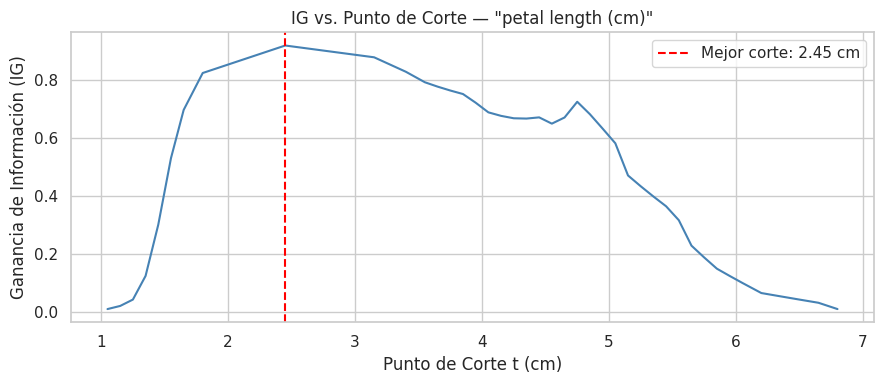

In [24]:
# Visualizar la Ganancia de Información en función del punto de corte
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tabla_splits['t'], tabla_splits['IG'], color='steelblue', linewidth=1.5)
ax.axvline(mejor_t, color='red', linestyle='--', label=f'Mejor corte: {mejor_t} cm')
ax.set_xlabel('Punto de Corte t (cm)')
ax.set_ylabel('Ganancia de Información (IG)')
ax.set_title(f'IG vs. Punto de Corte — "{col_disc}"')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Discretizar con el mejor punto de corte encontrado
df['petal_length_entropia'] = np.where(
    df['petal length (cm)'] <= mejor_t, 'Corto', 'Largo'
)

# Tabla de contingencia con la variable objetivo
tabla_cont = pd.crosstab(
    df['petal_length_entropia'], df['species_name'],
    margins=True
)
print(f'Distribución con corte en {mejor_t} cm:')
tabla_cont

Distribución con corte en 2.45 cm:


species_name,setosa,versicolor,virginica,All
petal_length_entropia,,,,
Corto,50,0,0,50
Largo,0,50,50,100
All,50,50,50,150


#### Opción B: Discretización con árbol de decisión (múltiples cortes)

Podemos automatizar la búsqueda de múltiples puntos de corte entrenando un `DecisionTreeClassifier` sobre la variable a discretizar. Los umbrales del árbol son los puntos de corte óptimos.

In [26]:
# Entrenar árbol de decisión para encontrar múltiples cortes
arbol = DecisionTreeClassifier(
    criterion='entropy',
    max_leaf_nodes=4,   # = número máximo de bins
    random_state=42
)
arbol.fit(df[['petal length (cm)']], df['species'])

# Extraer puntos de corte (se filtran los -2 que son nodos hoja)
cortes = np.sort(arbol.tree_.threshold[arbol.tree_.threshold != -2])
print(f'Puntos de corte encontrados por el árbol: {cortes.round(3)}')

# Crear bins con esos cortes
bins_tree = np.concatenate(([-np.inf], cortes, [np.inf]))
labels_tree = [f'bin_{i+1}' for i in range(len(bins_tree) - 1)]

df['petal_length_arbol'] = pd.cut(
    df['petal length (cm)'],
    bins=bins_tree,
    labels=labels_tree,
    include_lowest=True
)

print()
print('Conteo por bin:')
print(df.groupby('petal_length_arbol')['petal length (cm)'].agg(['min', 'max', 'count']))

Puntos de corte encontrados por el árbol: [2.45 4.75 5.15]

Conteo por bin:
                    min  max  count
petal_length_arbol                 
bin_1               1.0  1.9     50
bin_2               3.0  4.7     45
bin_3               4.8  5.1     21
bin_4               5.2  6.9     34


/tmp/ipykernel_1153/1974465798.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('petal_length_arbol')['petal length (cm)'].agg(['min', 'max', 'count']))


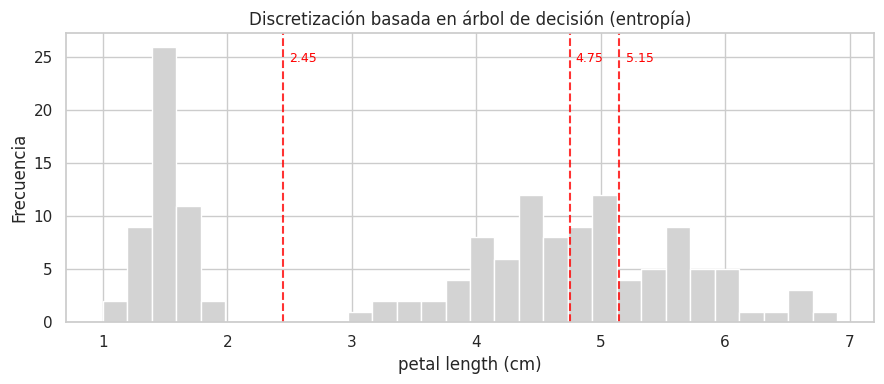

In [27]:
# Visualizar la discretización del árbol sobre la distribución original
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['petal length (cm)'], bins=30, color='lightgray', edgecolor='white', label='Original')
for c in cortes:
    ax.axvline(c, color='red', linestyle='--', alpha=0.8)
# Anotar los cortes
for i, c in enumerate(cortes):
    ax.text(c + 0.05, ax.get_ylim()[1] * 0.9, f'{c:.2f}', color='red', fontsize=9)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('Frecuencia')
ax.set_title('Discretización basada en árbol de decisión (entropía)')
plt.tight_layout()
plt.show()

### 4.4 Recodificación de Variables Categóricas — One-Hot Encoding

**Concepto:** muchos algoritmos requieren que todas las variables sean numéricas. Para variables categóricas, se crea una columna binaria (0 o 1) por cada categoría posible, llamada **variable dummy** o **one-hot**.

**Ejemplo:**  
`species = ['setosa', 'versicolor', 'virginica']` → tres columnas: `species_setosa`, `species_versicolor`, `species_virginica`.

> ⚠️ En regresión lineal y logística se elimina **una** de las columnas (la categoría de referencia) para evitar multicolinealidad perfecta.

In [28]:
# Usaremos la variable 'species_name' (setosa, versicolor, virginica)
ohe = OneHotEncoder(sparse_output=False, dtype=int)
encoded = ohe.fit_transform(df[['species_name']])

# Crear DataFrame con las columnas dummies
nombres_cols = [f'species_{cat}' for cat in ohe.categories_[0]]
df_dummies = pd.DataFrame(encoded, columns=nombres_cols)

print('Primeras 10 filas con One-Hot Encoding:')
pd.concat([df[['species_name']], df_dummies], axis=1).head(10)

Primeras 10 filas con One-Hot Encoding:


,species_name,species_setosa,species_versicolor,species_virginica
0,setosa,1,0,0
1,setosa,1,0,0
2,setosa,1,0,0
3,setosa,1,0,0
4,setosa,1,0,0
5,setosa,1,0,0
6,setosa,1,0,0
7,setosa,1,0,0
8,setosa,1,0,0
9,setosa,1,0,0


In [29]:
# Para regresión: eliminar una columna (la última) para evitar multicolinealidad
ohe_drop = OneHotEncoder(sparse_output=False, dtype=int, drop='first')
encoded_drop = ohe_drop.fit_transform(df[['species_name']])

nombres_drop = [f'species_{cat}' for cat in ohe_drop.categories_[0][1:]]
df_dummies_drop = pd.DataFrame(encoded_drop, columns=nombres_drop)

print('Con drop="first" (para regresión):')
pd.concat([df[['species_name']], df_dummies_drop], axis=1).head(10)

Con drop="first" (para regresión):


,species_name,species_versicolor,species_virginica
0,setosa,0,0
1,setosa,0,0
2,setosa,0,0
3,setosa,0,0
4,setosa,0,0
5,setosa,0,0
6,setosa,0,0
7,setosa,0,0
8,setosa,0,0
9,setosa,0,0


---
## 5. Resumen comparativo

A continuación se muestra un resumen de todas las técnicas aplicadas en este notebook.

In [30]:
resumen = pd.DataFrame([
    {
        'Técnica': 'Eliminar columnas con nulos',
        'Categoría': 'Reducción de Dimensionalidad',
        'Tipo': 'No supervisada',
        'Ventaja': 'Elimina ruido cuando no es posible imputar',
        'Limitación': 'Pérdida de información si el umbral es muy agresivo'
    },
    {
        'Técnica': 'Low Variance Filter',
        'Categoría': 'Reducción de Dimensionalidad',
        'Tipo': 'No supervisada',
        'Ventaja': 'Sencillo y rápido',
        'Limitación': 'Solo aplica a variables numéricas; requiere normalizar'
    },
    {
        'Técnica': 'Eliminación de correlacionadas',
        'Categoría': 'Reducción de Dimensionalidad',
        'Tipo': 'No supervisada',
        'Ventaja': 'Elimina redundancia sin perder información',
        'Limitación': 'No captura relaciones no lineales'
    },
    {
        'Técnica': 'Random Forest VarImp',
        'Categoría': 'Reducción de Dimensionalidad',
        'Tipo': 'Supervisada',
        'Ventaja': 'Captura relaciones no lineales; robusto',
        'Limitación': 'Computacionalmente costoso; sesgado a variables con más categorías'
    },
    {
        'Técnica': 'PCA',
        'Categoría': 'Reducción de Dimensionalidad',
        'Tipo': 'No supervisada',
        'Ventaja': 'Reduce dimensiones manteniendo máxima varianza; útil para visualización',
        'Limitación': 'Componentes no interpretables; solo para variables numéricas'
    },
    {
        'Técnica': 'Normalización Min-Max',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Rango fijo [0, 1]; intuitivo',
        'Limitación': 'Muy sensible a outliers'
    },
    {
        'Técnica': 'Normalización Z-Score',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Estándar estadístico; amplamente usado',
        'Limitación': 'Asume distribución aproximadamente normal'
    },
    {
        'Técnica': 'Decimal Scaling',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Simple; mantiene la estructura decimal',
        'Limitación': 'El rango resultante depende del máximo absoluto'
    },
    {
        'Técnica': 'Escalado Robusto',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Resistente a outliers (usa mediana e IQR)',
        'Limitación': 'Sin rango fijo de salida'
    },
    {
        'Técnica': 'Binning Igual Ancho',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Fácil de interpretar',
        'Limitación': 'Bins desbalanceados si la distribución es sesgada'
    },
    {
        'Técnica': 'Binning Igual Frecuencia',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Bins balanceados',
        'Limitación': 'Bordes irregulares, menos intuitivos'
    },
    {
        'Técnica': 'Discretización por Entropía',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'Supervisada',
        'Ventaja': 'Usa información de la clase; óptimo para clasificación',
        'Limitación': 'Requiere variable objetivo; riesgo de sobreajuste'
    },
    {
        'Técnica': 'One-Hot Encoding',
        'Categoría': 'Ingeniería de Características',
        'Tipo': 'No supervisada',
        'Ventaja': 'Necesario para algoritmos numéricos',
        'Limitación': 'Aumenta la dimensionalidad con muchas categorías'
    },
    {
        'Técnica': 'Information Value (IV) / WoE',
        'Categoría': 'Ñapa',
        'Tipo': 'Supervisada',
        'Ventaja': 'Escala interpretable; selección y transformación simultáneas; ideal para regresión logística',
        'Limitación': 'Solo para target binario; requiere discretización previa'
    },
])

resumen.style.set_properties(**{'text-align': 'left', 'font-size': '12px'}) \
    .set_table_styles([{'selector': 'th', 'props': 'text-align: center; background-color: #003865; color: white;'}])

,Técnica,Categoría,Tipo,Ventaja,Limitación
0,Eliminar columnas con nulos,Reducción de Dimensionalidad,No supervisada,Elimina ruido cuando no es posible imputar,Pérdida de información si el umbral es muy agresivo
1,Low Variance Filter,Reducción de Dimensionalidad,No supervisada,Sencillo y rápido,Solo aplica a variables numéricas; requiere normalizar
2,Eliminación de correlacionadas,Reducción de Dimensionalidad,No supervisada,Elimina redundancia sin perder información,No captura relaciones no lineales
3,Random Forest VarImp,Reducción de Dimensionalidad,Supervisada,Captura relaciones no lineales; robusto,Computacionalmente costoso; sesgado a variables con más categorías
4,PCA,Reducción de Dimensionalidad,No supervisada,Reduce dimensiones manteniendo máxima varianza; útil para visualización,Componentes no interpretables; solo para variables numéricas
5,Normalización Min-Max,Ingeniería de Características,No supervisada,"Rango fijo [0, 1]; intuitivo",Muy sensible a outliers
6,Normalización Z-Score,Ingeniería de Características,No supervisada,Estándar estadístico; amplamente usado,Asume distribución aproximadamente normal
7,Decimal Scaling,Ingeniería de Características,No supervisada,Simple; mantiene la estructura decimal,El rango resultante depende del máximo absoluto
8,Escalado Robusto,Ingeniería de Características,No supervisada,Resistente a outliers (usa mediana e IQR),Sin rango fijo de salida
9,Binning Igual Ancho,Ingeniería de Características,No supervisada,Fácil de interpretar,Bins desbalanceados si la distribución es sesgada


---
## 6. Ñapa: Information Value (IV) y Weight of Evidence (WoE)

### ¿Qué es el Information Value?

El **Information Value (IV)** es una métrica **supervisada** que mide la capacidad predictiva de una variable respecto a una variable objetivo **binaria**. Proviene del mundo del scoring crediticio pero se usa ampliamente en selección de variables para clasificación binaria.

Se calcula a partir del **Weight of Evidence (WoE)** de cada categoría o bin de la variable:

$$\text{WoE}_i = \ln\left(\frac{\% \text{Eventos}_i}{\% \text{No Eventos}_i}\right)$$

$$\text{IV} = \sum_{i=1}^{k} \left(\% \text{Eventos}_i - \% \text{No Eventos}_i\right) \times \text{WoE}_i$$

Donde:
- **Evento** = clase positiva (p. ej. `1`, el resultado de interés).
- **No Evento** = clase negativa (p. ej. `0`).
- El índice $i$ recorre cada categoría o bin de la variable predictora.

### Interpretación del IV

| IV | Poder Predictivo |
|----|------------------|
| < 0.02 | Inútil / sin poder predictivo |
| 0.02 – 0.10 | Débil |
| 0.10 – 0.30 | Medio |
| 0.30 – 0.50 | Fuerte |
| > 0.50 | Sospechoso (posible data leakage) |

> ⚠️ **Requisitos:**  
> 1. La variable objetivo debe ser **binaria** (0/1).  
> 2. La variable predictora debe estar **discretizada** (bins) antes de calcular WoE/IV.  
> 3. Ningún bin debe tener 0 eventos o 0 no-eventos (se usa suavizado).  

### Adaptación a Iris (multiclase → binaria)

Iris tiene 3 clases. Para demostrar IV haremos dos adaptaciones:
- **Caso A:** `setosa` (1) vs. `resto` (0) → clasificación binaria fácil.
- **Caso B:** `virginica` (1) vs. `resto` (0) → clasificación binaria más difícil.

In [31]:
# ── Funciones para calcular WoE e IV ──────────────────────────────────────────

def calcular_woe_iv(df_input, feature, target, epsilon=0.5):
    """
    Calcula el Weight of Evidence (WoE) y el Information Value (IV)
    para una variable predictora respecto a un target binario (0/1).

    Parámetros
    ----------
    df_input : DataFrame con la variable predictora y el target.
    feature  : nombre de la columna predictora (ya discretizada).
    target   : nombre de la columna objetivo binaria (0/1).
    epsilon  : suavizado para evitar log(0) cuando un bin tiene 0 eventos.

    Retorna
    -------
    tabla_woe : DataFrame con WoE e IV parcial por bin.
    iv_total  : float, IV total de la variable.
    """
    total_eventos    = df_input[target].sum() + epsilon
    total_no_eventos = (1 - df_input[target]).sum() + epsilon

    tabla = (
        df_input.groupby(feature)[target]
        .agg(
            n_total='count',
            n_eventos='sum'
        )
        .reset_index()
    )
    tabla['n_no_eventos'] = tabla['n_total'] - tabla['n_eventos']

    # Suavizado para bins con cero
    tabla['n_eventos']    = tabla['n_eventos']    + epsilon
    tabla['n_no_eventos'] = tabla['n_no_eventos'] + epsilon

    tabla['pct_eventos']    = tabla['n_eventos']    / total_eventos
    tabla['pct_no_eventos'] = tabla['n_no_eventos'] / total_no_eventos

    tabla['WoE']     = np.log(tabla['pct_eventos'] / tabla['pct_no_eventos'])
    tabla['IV_parcial'] = (tabla['pct_eventos'] - tabla['pct_no_eventos']) * tabla['WoE']

    iv_total = tabla['IV_parcial'].sum()
    return tabla.round(4), round(iv_total, 4)


def clasificar_iv(iv):
    """Devuelve la etiqueta de poder predictivo según el IV."""
    if iv < 0.02:  return '🔴 Inútil'
    if iv < 0.10:  return '🟠 Débil'
    if iv < 0.30:  return '🟡 Medio'
    if iv < 0.50:  return '🟢 Fuerte'
    return '⚠️ Sospechoso (posible data leakage)'


print('✅ Funciones WoE / IV definidas.')

✅ Funciones WoE / IV definidas.


In [32]:
# ── Preparar los dos escenarios binarios ──────────────────────────────────────
df_iv = df[iris.feature_names + ['species_name']].copy()

# Caso A: setosa (1) vs. resto (0)
df_iv['target_setosa']   = (df_iv['species_name'] == 'setosa').astype(int)

# Caso B: virginica (1) vs. resto (0)
df_iv['target_virginica'] = (df_iv['species_name'] == 'virginica').astype(int)

print('Distribución Caso A — setosa vs. resto:')
print(df_iv['target_setosa'].value_counts().to_string())
print()
print('Distribución Caso B — virginica vs. resto:')
print(df_iv['target_virginica'].value_counts().to_string())

Distribución Caso A — setosa vs. resto:
target_setosa
0    100
1     50

Distribución Caso B — virginica vs. resto:
target_virginica
0    100
1     50


In [33]:
# ── Discretizar todas las variables numéricas con igual frecuencia (5 bins) ───
# WoE/IV requiere variables discretizadas
N_BINS_IV = 5
kbd_iv = KBinsDiscretizer(n_bins=N_BINS_IV, encode='ordinal', strategy='quantile')

X_disc = kbd_iv.fit_transform(df_iv[iris.feature_names])
for i, feat in enumerate(iris.feature_names):
    df_iv[feat + '_bin'] = X_disc[:, i].astype(int)

# Mostrar bordes de bins de una variable
print(f'Bordes de bins para "{iris.feature_names[2]}":')
print(kbd_iv.bin_edges_[2].round(3))
print()
print('Primeras 5 filas con bins:')
bin_cols = [f + '_bin' for f in iris.feature_names]
df_iv[iris.feature_names + bin_cols].head()

Bordes de bins para "petal length (cm)":
[1.   1.5  3.9  4.64 5.32 6.9 ]

Primeras 5 filas con bins:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),sepal length (cm)_bin,sepal width (cm)_bin,petal length (cm)_bin,petal width (cm)_bin
0,5.1,3.5,1.4,0.2,1,4,0,1
1,4.9,3.0,1.4,0.2,0,2,0,1
2,4.7,3.2,1.3,0.2,0,3,0,1
3,4.6,3.1,1.5,0.2,0,3,1,1
4,5.0,3.6,1.4,0.2,1,4,0,1


#### Caso A: `setosa` (1) vs. `resto` (0)

In [34]:
# Calcular IV de cada variable para Caso A
print('=' * 55)
print('  CASO A — setosa (1) vs. resto (0)')
print('=' * 55)

iv_resumen_a = []
for feat in iris.feature_names:
    tabla_woe, iv_total = calcular_woe_iv(
        df_iv, feat + '_bin', 'target_setosa'
    )
    iv_resumen_a.append({
        'Variable': feat,
        'IV': iv_total,
        'Poder Predictivo': clasificar_iv(iv_total)
    })

iv_df_a = pd.DataFrame(iv_resumen_a).sort_values('IV', ascending=False).reset_index(drop=True)
iv_df_a

  CASO A — setosa (1) vs. resto (0)


,Variable,IV,Poder Predictivo
0,petal length (cm),6.1052,⚠️ Sospechoso (posible data leakage)
1,petal width (cm),5.0568,⚠️ Sospechoso (posible data leakage)
2,sepal length (cm),4.1247,⚠️ Sospechoso (posible data leakage)
3,sepal width (cm),2.4295,⚠️ Sospechoso (posible data leakage)


In [35]:
# Tabla WoE detallada de la variable con mayor IV (Caso A)
mejor_var_a = iv_df_a.loc[0, 'Variable']
tabla_woe_a, iv_a = calcular_woe_iv(df_iv, mejor_var_a + '_bin', 'target_setosa')

print(f'Tabla WoE — "{mejor_var_a}"  |  IV = {iv_a}  |  {clasificar_iv(iv_a)}')
print()
tabla_woe_a[[
    mejor_var_a + '_bin', 'n_total', 'n_eventos', 'n_no_eventos',
    'pct_eventos', 'pct_no_eventos', 'WoE', 'IV_parcial'
]]

Tabla WoE — "petal length (cm)"  |  IV = 6.1052  |  ⚠️ Sospechoso (posible data leakage)



,petal length (cm)_bin,n_total,n_eventos,n_no_eventos,pct_eventos,pct_no_eventos,WoE,IV_parcial
0,0,24,24.5,0.5,0.4851,0.0050,4.5800,2.1992
1,1,34,26.5,8.5,0.5248,0.0846,1.8253,0.8034
2,2,32,0.5,32.5,0.0099,0.3234,-3.4862,1.0929
3,3,30,0.5,30.5,0.0099,0.3035,-3.4227,1.0048
4,4,30,0.5,30.5,0.0099,0.3035,-3.4227,1.0048


#### Caso B: `virginica` (1) vs. `resto` (0)

In [36]:
print('=' * 55)
print('  CASO B — virginica (1) vs. resto (0)')
print('=' * 55)

iv_resumen_b = []
for feat in iris.feature_names:
    tabla_woe, iv_total = calcular_woe_iv(
        df_iv, feat + '_bin', 'target_virginica'
    )
    iv_resumen_b.append({
        'Variable': feat,
        'IV': iv_total,
        'Poder Predictivo': clasificar_iv(iv_total)
    })

iv_df_b = pd.DataFrame(iv_resumen_b).sort_values('IV', ascending=False).reset_index(drop=True)
iv_df_b

  CASO B — virginica (1) vs. resto (0)


,Variable,IV,Poder Predictivo
0,petal width (cm),6.1815,⚠️ Sospechoso (posible data leakage)
1,petal length (cm),5.8050,⚠️ Sospechoso (posible data leakage)
2,sepal length (cm),2.5942,⚠️ Sospechoso (posible data leakage)
3,sepal width (cm),0.3485,🟢 Fuerte


#### Visualización: IV comparativo y curvas WoE

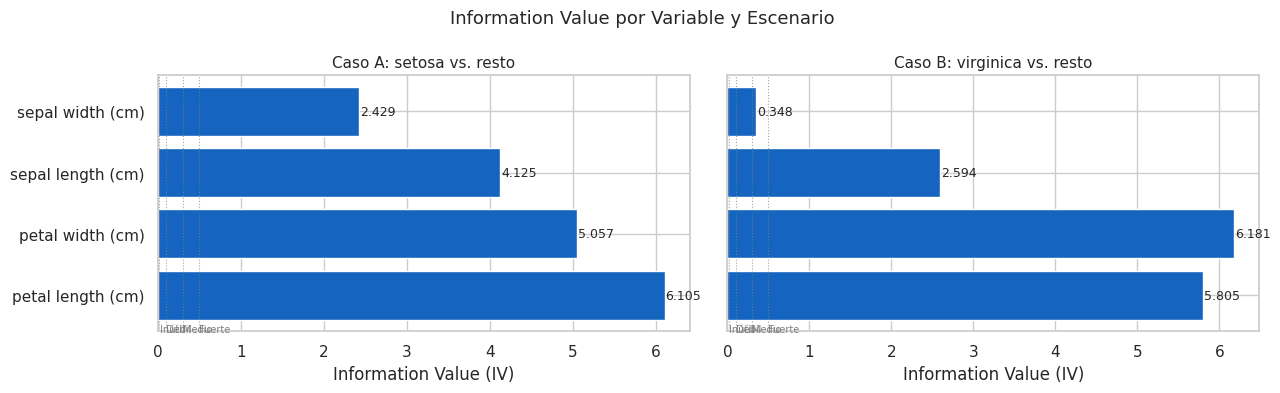

In [37]:
# ── Gráfica 1: IV de todas las variables en los dos escenarios ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

umbrales = [
    (0.02, 'Inútil',    '#e0e0e0'),
    (0.10, 'Débil',     '#ffccbc'),
    (0.30, 'Medio',     '#fff9c4'),
    (0.50, 'Fuerte',    '#c8e6c9'),
]

for ax, iv_df, titulo in zip(
    axes,
    [iv_df_a, iv_df_b],
    ['Caso A: setosa vs. resto', 'Caso B: virginica vs. resto']
):
    colores_bar = [
        '#1565C0' if iv >= 0.30 else '#42A5F5' if iv >= 0.10 else '#90CAF9'
        for iv in iv_df['IV']
    ]
    bars = ax.barh(iv_df['Variable'], iv_df['IV'], color=colores_bar, edgecolor='white')
    for bar, iv_val in zip(bars, iv_df['IV']):
        ax.text(
            bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{iv_val:.3f}', va='center', fontsize=9
        )
    # Líneas de referencia
    for val, lbl, _ in umbrales:
        ax.axvline(val, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        ax.text(val + 0.002, -0.6, lbl, fontsize=7, color='gray')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Information Value (IV)')
    ax.invert_yaxis()

fig.suptitle('Information Value por Variable y Escenario', fontsize=13)
plt.tight_layout()
plt.show()

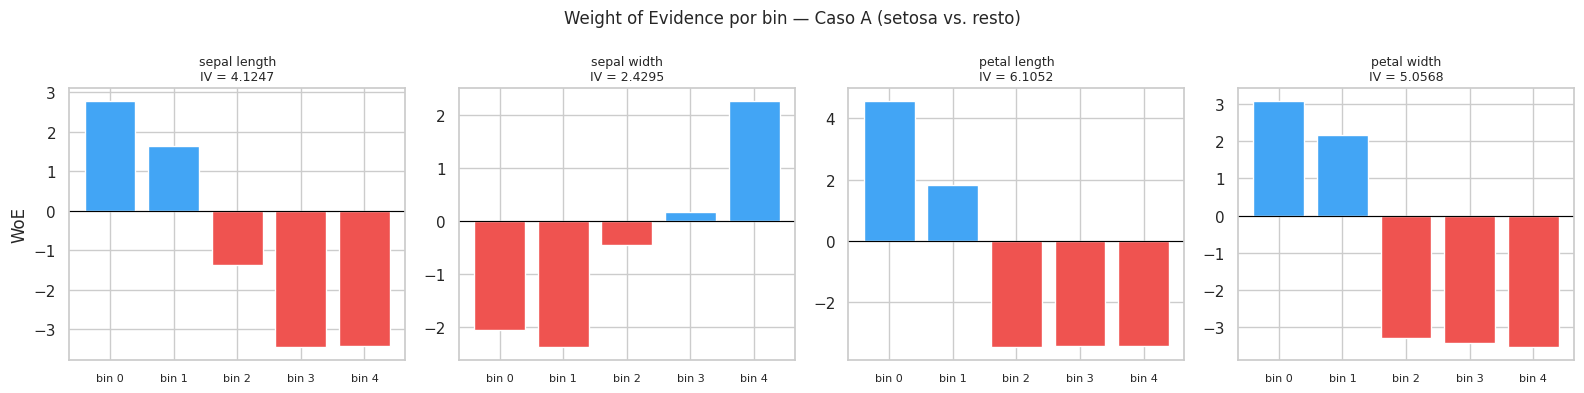


📌 WoE positivo → el bin tiene más "eventos" (setosas) de lo esperado.
   WoE negativo → el bin tiene menos "eventos" de lo esperado.


In [38]:
# ── Gráfica 2: Curvas WoE para cada variable (Caso A) ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, iris.feature_names):
    tabla_w, iv_t = calcular_woe_iv(df_iv, feat + '_bin', 'target_setosa')
    bin_labels = [f'bin {int(b)}' for b in tabla_w[feat + '_bin']]

    colores_woe = ['#EF5350' if w < 0 else '#42A5F5' for w in tabla_w['WoE']]
    ax.bar(bin_labels, tabla_w['WoE'], color=colores_woe, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{feat.replace(" (cm)","")}\nIV = {iv_t}', fontsize=9)
    ax.set_ylabel('WoE' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Weight of Evidence por bin — Caso A (setosa vs. resto)', fontsize=12)
plt.tight_layout()
plt.show()

print('\n📌 WoE positivo → el bin tiene más "eventos" (setosas) de lo esperado.')
print('   WoE negativo → el bin tiene menos "eventos" de lo esperado.')

In [39]:
# ── Selección de variables según umbral de IV ─────────────────────────────────
UMBRAL_IV = 0.10  # Conservar variables con IV >= 0.10 (poder medio o superior)

print(f'Umbral IV aplicado: {UMBRAL_IV}  →  conservar variables con poder "Medio" o superior\n')

for caso, iv_df, nombre in [
    ('A', iv_df_a, 'setosa vs. resto'),
    ('B', iv_df_b, 'virginica vs. resto')
]:
    seleccionadas = iv_df.query('IV >= @UMBRAL_IV')['Variable'].tolist()
    descartadas   = iv_df.query('IV <  @UMBRAL_IV')['Variable'].tolist()
    print(f'Caso {caso} ({nombre}):')
    print(f'  ✅ Seleccionadas : {seleccionadas}')
    print(f'  ❌ Descartadas   : {descartadas}')
    print()

Umbral IV aplicado: 0.1  →  conservar variables con poder "Medio" o superior

Caso A (setosa vs. resto):
  ✅ Seleccionadas : ['petal length (cm)', 'petal width (cm)', 'sepal length (cm)', 'sepal width (cm)']
  ❌ Descartadas   : []

Caso B (virginica vs. resto):
  ✅ Seleccionadas : ['petal width (cm)', 'petal length (cm)', 'sepal length (cm)', 'sepal width (cm)']
  ❌ Descartadas   : []



#### ¿Para qué se usa WoE en la práctica?

El WoE tiene un uso adicional importante: **transformar** las variables originales reemplazando cada categoría por su valor WoE. Esto es útil porque:

1. Convierte variables categóricas en numéricas con una escala significativa (a diferencia de One-Hot Encoding, no aumenta la dimensionalidad).
2. Linealiza la relación entre el predictor y el log-odds de la variable objetivo → ideal para regresión logística.
3. Maneja automáticamente categorías con pocos datos (suavizado `epsilon`).

In [40]:
# ── Transformación WoE de todas las variables (Caso A) ────────────────────────
df_woe = df_iv[iris.feature_names + ['target_setosa']].copy()

for feat in iris.feature_names:
    tabla_w, _ = calcular_woe_iv(df_iv, feat + '_bin', 'target_setosa')
    # Mapa bin → WoE
    mapa_woe = dict(zip(tabla_w[feat + '_bin'], tabla_w['WoE']))
    df_woe[feat + '_woe'] = df_iv[feat + '_bin'].map(mapa_woe)

woe_cols = [f + '_woe' for f in iris.feature_names]
print('Primeras 10 filas — variables transformadas a WoE:')
df_woe[iris.feature_names + woe_cols].head(10).round(3)

Primeras 10 filas — variables transformadas a WoE:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),sepal length (cm)_woe,sepal width (cm)_woe,petal length (cm)_woe,petal width (cm)_woe
0,5.1,3.5,1.4,0.2,1.651,2.266,4.580,2.154
1,4.9,3.0,1.4,0.2,2.792,-0.460,4.580,2.154
2,4.7,3.2,1.3,0.2,2.792,0.160,4.580,2.154
3,4.6,3.1,1.5,0.2,2.792,0.160,1.825,2.154
4,5.0,3.6,1.4,0.2,1.651,2.266,4.580,2.154
5,5.4,3.9,1.7,0.4,1.651,2.266,1.825,2.154
6,4.6,3.4,1.4,0.3,2.792,2.266,4.580,2.154
7,5.0,3.4,1.5,0.2,1.651,2.266,1.825,2.154
8,4.4,2.9,1.4,0.2,2.792,-2.388,4.580,2.154
9,4.9,3.1,1.5,0.1,2.792,0.160,1.825,3.086


In [41]:
# ── Resumen final IV ──────────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════╗')
print('║           RESUMEN — Information Value (IV)               ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Caso A: setosa vs. resto                                ║')
for _, row in iv_df_a.iterrows():
    print(f'║    {row["Variable"]:<28}  IV = {row["IV"]:.3f}  {row["Poder Predictivo"]} ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Caso B: virginica vs. resto                             ║')
for _, row in iv_df_b.iterrows():
    print(f'║    {row["Variable"]:<28}  IV = {row["IV"]:.3f}  {row["Poder Predictivo"]} ║')
print('╚══════════════════════════════════════════════════════════╝')
print()
print('📌 Interpretación:')
print('   · Caso A: petal length y petal width son altamente predictivas de setosa.')
print('   · Caso B: las mismas variables distinguen bien virginica del resto,')
print('     pero con IVs menores porque la separación es menos perfecta.')

╔══════════════════════════════════════════════════════════╗
║           RESUMEN — Information Value (IV)               ║
╠══════════════════════════════════════════════════════════╣
║  Caso A: setosa vs. resto                                ║
║    petal length (cm)             IV = 6.105  ⚠️ Sospechoso (posible data leakage) ║
║    petal width (cm)              IV = 5.057  ⚠️ Sospechoso (posible data leakage) ║
║    sepal length (cm)             IV = 4.125  ⚠️ Sospechoso (posible data leakage) ║
║    sepal width (cm)              IV = 2.429  ⚠️ Sospechoso (posible data leakage) ║
╠══════════════════════════════════════════════════════════╣
║  Caso B: virginica vs. resto                             ║
║    petal width (cm)              IV = 6.181  ⚠️ Sospechoso (posible data leakage) ║
║    petal length (cm)             IV = 5.805  ⚠️ Sospechoso (posible data leakage) ║
║    sepal length (cm)             IV = 2.594  ⚠️ Sospechoso (posible data leakage) ║
║    sepal width (cm)           

#### IV vs. otras métricas de selección de variables

| Métrica | Tipo | Target requerido | Variables | Interpretable |
|---------|------|-----------------|-----------|---------------|
| Low Variance Filter | No supervisada | No | Numéricas | Sí |
| Correlación de Pearson | No supervisada | No | Numéricas | Sí |
| Chi-cuadrado | No supervisada / supervisada | Opcional | Categóricas | Moderado |
| Random Forest VarImp | Supervisada | Sí (multiclase OK) | Numéricas y categ. | Moderado |
| **Information Value (IV)** | **Supervisada** | **Sí (solo binario)** | **Numéricas (binneadas) y categ.** | **Sí — escala intuitiva** |

> 💡 **Cuándo usar IV:** cuando tu objetivo es binario (fraude/no fraude, churn/no churn, default/no default) y quieres una métrica sencilla de explicar a stakeholders no técnicos.

---
## 🎯 Ejercicios propuestos

1. **Correlación con chi-cuadrado:** la sección 3.3 usó correlación de Pearson (variables continuas). Aplica una prueba chi-cuadrado para evaluar la dependencia entre `petal_length_entropia` (variable discretizada) y `species_name`. ¿Cuál es tu conclusión?

2. **Selección Forward:** implementa una selección forward usando como métrica la exactitud (*accuracy*) de un árbol de decisión. Empieza con el conjunto vacío e itera hasta no mejorar el desempeño.

3. **Comparación de normalizaciones en KNN:** usa las versiones normalizadas de las variables para entrenar un KNN y compara la exactitud con la versión sin normalizar. ¿Qué método de normalización da mejores resultados?

4. **PCA 3D:** proyecta los datos en 3 componentes y genera un gráfico 3D usando `matplotlib` con `Axes3D`. ¿Cuánta varianza adicional captura PC3 sobre PC2?

5. **Efecto del binning en un clasificador:** entrena un árbol de decisión usando `petal_length_igulancho_lbl` y otro con `petal_length_entropia`. ¿Cuál tiene mayor *accuracy*? ¿Por qué?

6. **IV con diferente número de bins:** recalcula el IV de `petal length (cm)` para el Caso A variando el número de bins (3, 5, 7 y 10). ¿Cómo cambia el IV? ¿A partir de cuántos bins el IV se estabiliza?

7. **WoE en regresión logística:** usa las variables transformadas a WoE (`_woe`) del Caso A para entrenar una regresión logística. Compara la exactitud con la versión entrenada sobre las variables originales.

---
*Fin del notebook — Semana 7 | Introducción a la Minería de Datos*

In [42]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    KBinsDiscretizer, OneHotEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import pearsonr

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
from scipy.stats import chi2_contingency
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
# 1.
# Tabla de contingencia
tabla_chi = pd.crosstab(
    df['petal_length_entropia'],
    df['species_name']
)

print('Tabla de contingencia:')
print(tabla_chi)

# Prueba chi-cuadrado
chi2, p_valor, gl, esperados = chi2_contingency(tabla_chi)

print('\nResultados prueba Chi-cuadrado:')
print(f'Estadístico chi-cuadrado: {chi2:.4f}')
print(f'Grados de libertad: {gl}')
print(f'Valor-p: {p_valor:.6e}')

# Frecuencias esperadas
esperados_df = pd.DataFrame(
    esperados,
    index=tabla_chi.index,
    columns=tabla_chi.columns
)

✅ Librerías cargadas correctamente.
Tabla de contingencia:
species_name           setosa  versicolor  virginica
petal_length_entropia                               
Corto                      50           0          0
Largo                       0          50         50

Resultados prueba Chi-cuadrado:
Estadístico chi-cuadrado: 150.0000
Grados de libertad: 2
Valor-p: 2.678637e-33


**Conclusión:**
Como el valor-p es prácticamente cero, se rechaza la hipótesis nula de independencia. Por tanto, existe una relación estadísticamente significativa entre **petal_length_entropia** y **species_name**.

In [44]:
# 2).
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

def evaluar_arbol(features):
    """
    Entrena un árbol de decisión usando un subconjunto de variables
    y retorna la exactitud en test.
    """
    modelo = DecisionTreeClassifier(random_state=42)
    modelo.fit(X_train[features], y_train)
    pred = modelo.predict(X_test[features])
    return accuracy_score(y_test, pred)


variables_disponibles = list(X.columns)
variables_seleccionadas = []
mejor_accuracy = 0

historial_forward = []

while len(variables_disponibles) > 0:
    resultados_iteracion = []

    for var in variables_disponibles:
        candidato = variables_seleccionadas + [var]
        acc = evaluar_arbol(candidato)

        resultados_iteracion.append({
            'Variable candidata': var,
            'Variables usadas': candidato,
            'Accuracy': acc
        })

    resultados_df = pd.DataFrame(resultados_iteracion)
    mejor_fila = resultados_df.sort_values('Accuracy', ascending=False).iloc[0]

    if mejor_fila['Accuracy'] > mejor_accuracy:
        nueva_variable = mejor_fila['Variable candidata']
        variables_seleccionadas.append(nueva_variable)
        variables_disponibles.remove(nueva_variable)
        mejor_accuracy = mejor_fila['Accuracy']

        historial_forward.append({
            'Iteración': len(variables_seleccionadas),
            'Variable agregada': nueva_variable,
            'Accuracy': mejor_accuracy,
            'Variables seleccionadas': variables_seleccionadas.copy()
        })
    else:
        break

historial_forward_df = pd.DataFrame(historial_forward)

print('Historial de selección Forward:')
print(historial_forward_df)

print('\nVariables finales seleccionadas:')
print(variables_seleccionadas)

print(f'\nMejor accuracy obtenido: {mejor_accuracy:.4f}')

Historial de selección Forward:
   Iteración Variable agregada  Accuracy Variables seleccionadas
0          1  petal width (cm)  0.933333      [petal width (cm)]

Variables finales seleccionadas:
['petal width (cm)']

Mejor accuracy obtenido: 0.9333


**Conclusión:**
La selección forward escogió principalmente **petal width (cm)** porque, por sí sola, permite clasificar bastante bien las especies. Al agregar más variables, el desempeño no mejoró en la partición de prueba, por lo que el algoritmo se detuvo.

In [45]:
# 3).
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

resultados_knn = []

# -------------------------
# 1. Sin normalizar
# -------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

resultados_knn.append({
    'Método': 'Sin normalizar',
    'Accuracy': accuracy_score(y_test, pred)
})

# -------------------------
# 2. Min-Max
# -------------------------
scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_mm, y_train)
pred = knn.predict(X_test_mm)

resultados_knn.append({
    'Método': 'Min-Max',
    'Accuracy': accuracy_score(y_test, pred)
})

# -------------------------
# 3. Z-Score
# -------------------------
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_z, y_train)
pred = knn.predict(X_test_z)

resultados_knn.append({
    'Método': 'Z-Score',
    'Accuracy': accuracy_score(y_test, pred)
})

# -------------------------
# 4. Decimal Scaling
# -------------------------
max_abs = X_train.abs().max()
d = max_abs.apply(lambda x: len(str(int(abs(x)))) if x != 0 else 1)

X_train_dec = X_train / (10 ** d)
X_test_dec = X_test / (10 ** d)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_dec, y_train)
pred = knn.predict(X_test_dec)

resultados_knn.append({
    'Método': 'Decimal Scaling',
    'Accuracy': accuracy_score(y_test, pred)
})

# -------------------------
# 5. Escalado Robusto
# -------------------------
scaler = RobustScaler()
X_train_rob = scaler.fit_transform(X_train)
X_test_rob = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_rob, y_train)
pred = knn.predict(X_test_rob)

resultados_knn.append({
    'Método': 'Robusto',
    'Accuracy': accuracy_score(y_test, pred)
})

resultados_knn_df = pd.DataFrame(resultados_knn).sort_values(
    'Accuracy',
    ascending=False
)

print(resultados_knn_df)

            Método  Accuracy
0   Sin normalizar  0.977778
3  Decimal Scaling  0.977778
1          Min-Max  0.933333
2          Z-Score  0.911111
4          Robusto  0.888889


**Conclusión:**
En este caso, la versión sin normalizar y la normalización por **Decimal Scaling** obtienen el mejor desempeño. Esto ocurre porque las variables del dataset Iris están en la misma unidad de medida, centímetros, y no presentan escalas extremadamente diferentes. Por tanto, normalizar no necesariamente mejora el KNN en esta base específica.

  Componente  Varianza Explicada (%)  Varianza Acumulada (%)
0        PC1                   72.96                   72.96
1        PC2                   22.85                   95.81
2        PC3                    3.67                   99.48


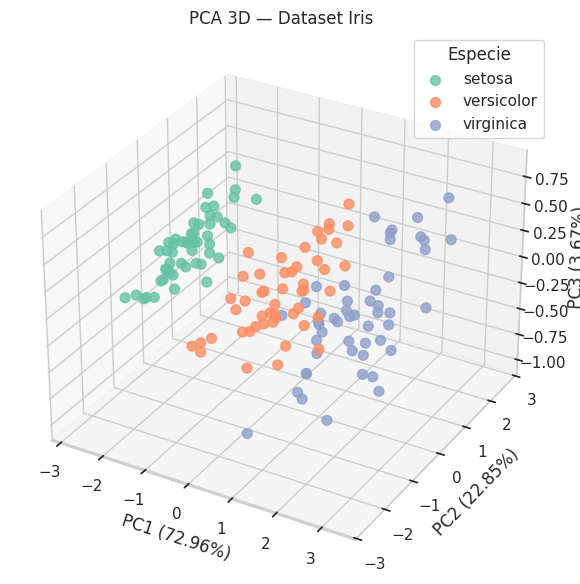

Varianza acumulada con 2 componentes: 95.81%
Varianza acumulada con 3 componentes: 99.48%
Varianza adicional capturada por PC3: 3.67%


In [46]:
# 4)
X_iris = df[iris.feature_names]
y_names = df['species_name']

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# PCA con 3 componentes
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

varianza_3d = pca_3d.explained_variance_ratio_
varianza_acum_3d = np.cumsum(varianza_3d)

pca_3d_df = pd.DataFrame({
    'Componente': ['PC1', 'PC2', 'PC3'],
    'Varianza Explicada (%)': (varianza_3d * 100).round(2),
    'Varianza Acumulada (%)': (varianza_acum_3d * 100).round(2)
})

print(pca_3d_df)

# DataFrame para graficar
df_pca_3d = pd.DataFrame(
    X_pca_3d,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca_3d['species_name'] = y_names.values

# Gráfico 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for especie, grupo in df_pca_3d.groupby('species_name'):
    ax.scatter(
        grupo['PC1'],
        grupo['PC2'],
        grupo['PC3'],
        label=especie,
        s=50,
        alpha=0.8
    )

ax.set_xlabel(f'PC1 ({varianza_3d[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({varianza_3d[1]*100:.2f}%)')
ax.set_zlabel(f'PC3 ({varianza_3d[2]*100:.2f}%)')
ax.set_title('PCA 3D — Dataset Iris')
ax.legend(title='Especie')

plt.tight_layout()
plt.show()

print(f'Varianza acumulada con 2 componentes: {varianza_acum_3d[1]*100:.2f}%')
print(f'Varianza acumulada con 3 componentes: {varianza_acum_3d[2]*100:.2f}%')
print(f'Varianza adicional capturada por PC3: {varianza_3d[2]*100:.2f}%')

**Conclusión:**
Con dos componentes principales se explica aproximadamente el 95.81% de la varianza total. Al agregar PC3, la varianza acumulada sube a aproximadamente 99.48%. Por tanto, PC3 captura una varianza adicional de 3.67 puntos porcentuales.

In [47]:
#5).
# Asegurar que las variables estén en formato numérico
df['petal_length_entropia_num'] = np.where(
    df['petal_length_entropia'] == 'Corto',
    0,
    1
)

X_binning_ancho = df[['petal_length_igulancho']]
X_binning_entropia = df[['petal_length_entropia_num']]
y = df['species']

# Mismo split para ambos modelos
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_binning_ancho,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train_e, X_test_e, _, _ = train_test_split(
    X_binning_entropia,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Árbol con binning de igual ancho
arbol_ancho = DecisionTreeClassifier(random_state=42)
arbol_ancho.fit(X_train_a, y_train)
pred_ancho = arbol_ancho.predict(X_test_a)

acc_ancho = accuracy_score(y_test, pred_ancho)

# Árbol con binning por entropía
arbol_entropia = DecisionTreeClassifier(random_state=42)
arbol_entropia.fit(X_train_e, y_train)
pred_entropia = arbol_entropia.predict(X_test_e)

acc_entropia = accuracy_score(y_test, pred_entropia)

resultados_binning = pd.DataFrame({
    'Método de binning': ['Igual ancho', 'Entropía'],
    'Accuracy': [acc_ancho, acc_entropia]
})

print(resultados_binning)

  Método de binning  Accuracy
0       Igual ancho  0.911111
1          Entropía  0.666667


**Conclusión:**
El binning de igual ancho obtiene mayor exactitud. Aunque el corte por entropía separa muy bien a setosa del resto, solo genera dos categorías: Corto y Largo. Eso impide diferenciar correctamente entre versicolor y virginica, porque ambas quedan principalmente en la categoría Largo.

   Número de bins      IV
0               3  9.1458
1               5  6.1052
2               7  6.1207
3              10  6.1341


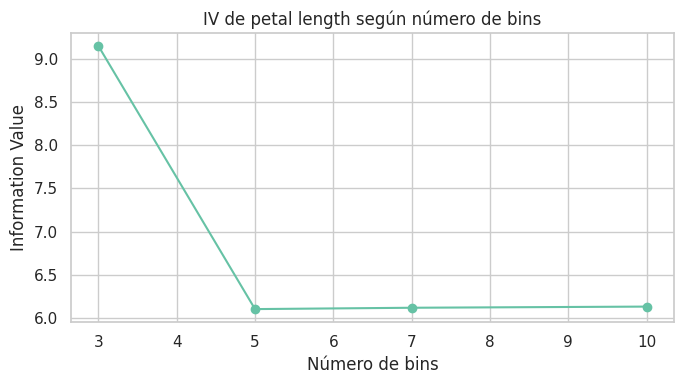

In [48]:
#6).
iv_bins_resultados = []

for n_bins in [3, 5, 7, 10]:

    df_temp = df[iris.feature_names + ['species_name']].copy()
    df_temp['target_setosa'] = (
        df_temp['species_name'] == 'setosa'
    ).astype(int)

    kbd_temp = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',
        strategy='quantile'
    )

    df_temp['petal_length_bin'] = kbd_temp.fit_transform(
        df_temp[['petal length (cm)']]
    ).astype(int)

    tabla_woe_temp, iv_total_temp = calcular_woe_iv(
        df_temp,
        'petal_length_bin',
        'target_setosa'
    )

    iv_bins_resultados.append({
        'Número de bins': n_bins,
        'IV': iv_total_temp
    })

iv_bins_df = pd.DataFrame(iv_bins_resultados)

print(iv_bins_df)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    iv_bins_df['Número de bins'],
    iv_bins_df['IV'],
    marker='o'
)

ax.set_title('IV de petal length según número de bins')
ax.set_xlabel('Número de bins')
ax.set_ylabel('Information Value')
ax.grid(True)

plt.tight_layout()
plt.show()

**Conclusión:**
El IV es muy alto en todos los casos, lo cual indica que petal length (cm) tiene una capacidad predictiva muy fuerte para separar setosa del resto. A partir de 5 bins, el IV se estabiliza aproximadamente alrededor de 6.1, ya que los valores con 5, 7 y 10 bins cambian muy poco.

In [49]:
#7).
# Variables originales
X_original = df_woe[iris.feature_names]

# Variables transformadas a WoE
woe_cols = [f + '_woe' for f in iris.feature_names]
X_woe = df_woe[woe_cols]

# Target binario: setosa vs resto
y = df_woe['target_setosa']

# Split con índices para usar exactamente la misma partición
idx_train, idx_test = train_test_split(
    df_woe.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train_original = X_original.loc[idx_train]
X_test_original = X_original.loc[idx_test]

X_train_woe = X_woe.loc[idx_train]
X_test_woe = X_woe.loc[idx_test]

y_train = y.loc[idx_train]
y_test = y.loc[idx_test]

# Modelo con variables originales
log_original = LogisticRegression(max_iter=1000, random_state=42)
log_original.fit(X_train_original, y_train)
pred_original = log_original.predict(X_test_original)

acc_original = accuracy_score(y_test, pred_original)

# Modelo con variables WoE
log_woe = LogisticRegression(max_iter=1000, random_state=42)
log_woe.fit(X_train_woe, y_train)
pred_woe = log_woe.predict(X_test_woe)

acc_woe = accuracy_score(y_test, pred_woe)

comparacion_logistica = pd.DataFrame({
    'Modelo': ['Regresión logística original', 'Regresión logística con WoE'],
    'Accuracy': [acc_original, acc_woe]
})

print(comparacion_logistica)

                         Modelo  Accuracy
0  Regresión logística original       1.0
1   Regresión logística con WoE       1.0


**Conclusión:**
Ambas regresiones logísticas obtienen una exactitud perfecta en esta partición. Esto se debe a que el problema setosa vs. resto es muy fácil de separar en el dataset Iris, especialmente usando variables relacionadas con el pétalo.